# Machine Learning for Beginners: Classification & Regression

**Course:** Supervised Machine Learning  
**Audience:** Complete beginners with basic Python knowledge

---

## What You Will Learn

This notebook teaches core supervised machine learning concepts in simple language:

1. **ML Foundations** — features, train/test split, overfitting, evaluation
2. **Regression** — predicting numbers (e.g., house prices)
3. **Classification** — predicting categories (e.g., spam vs not spam)
4. **Decision Trees** — rule-based models with branches
5. **Naive Bayes** — probability-based classification
6. **Support Vector Machines (SVM)** — finding the best separating boundary
7. **Ensemble Learning** — combining multiple models
8. **K-Nearest Neighbors (KNN)** — learning by similarity

**How to use this notebook:**
- Run every cell **from top to bottom** (Shift + Enter).
- Read the markdown explanation **before** each code cell.
- Libraries used: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`.


## Shared Setup — Import Libraries

We load all libraries once at the start. Every section reuses these imports.

| Library | Purpose |
|---|---|
| **NumPy** | Fast numeric arrays and math |
| **Pandas** | Tables (DataFrames) for data |
| **Matplotlib / Seaborn** | Charts and visualizations |
| **scikit-learn** | Ready-made ML algorithms |


In [1]:
# Suppress minor warnings so output stays readable for beginners
import warnings
warnings.filterwarnings('ignore')

# Core data and math libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# scikit-learn: models, data splitting, metrics, preprocessing
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, BaggingClassifier
)

# Consistent random seed for reproducible results
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Clean chart style for classroom teaching
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (8, 5)


def plot_decision_regions(X, y, classifier, title='Decision Boundary', h=0.02):
    """Draw colored regions showing how a 2-D classifier separates classes."""
    markers = ('o', 's', '^', 'D', 'v')
    colors = ('#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    Z = classifier.predict(np.c_[xx1.ravel(), xx2.ravel()])
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.35, cmap=cmap)
    for idx, cl in enumerate(np.unique(y)):
        mask = y == cl
        plt.scatter(X[mask, 0], X[mask, 1], c=colors[idx], marker=markers[idx],
                    edgecolors='k', s=60, label=f'Class {cl}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend(loc='best')

print('Setup complete. All libraries loaded successfully.')


Setup complete. All libraries loaded successfully.


---

# Part 0: Machine Learning Foundations

Before we train any model, we need shared vocabulary and ideas that apply to **every** algorithm in this notebook.


## What Is Supervised Learning?

### Simple Definition
**Supervised learning** means teaching a computer to predict an output by showing it many **labeled examples** — each example includes both the **input** (features) and the **correct answer** (target).

### Real-Life Example
A teacher shows students flashcards: a photo of a cat labeled "cat," a photo of a dog labeled "dog." After enough examples, students can label new photos they have never seen.

### When to Use It
Use supervised learning when:
- You have historical data with known outcomes.
- You want to predict a **number** (regression) or a **category** (classification).

### Key Theory
The model learns a function:  
$$f(\text{features}) \rightarrow \text{target}$$

Two main types in this notebook:
- **Regression** — target is continuous (price, temperature).
- **Classification** — target is a category (spam/not spam, flower species).


## Features and Target Variable

### Simple Definition
- **Features (X):** The input columns the model uses to make a prediction (e.g., house size, number of bedrooms).
- **Target (y):** The value we want to predict (e.g., house price, flower type).

### Real-Life Example
Predicting exam pass/fail: features = study hours, attendance; target = Pass or Fail.

### When to Use This Idea
Always — every supervised model needs clearly defined features and a single target.

### Common Mistakes Beginners Make
- Including the target column accidentally as a feature.
- Using columns that won't exist at prediction time (e.g., "final grade" when predicting mid-term).


In [2]:
# Example: create a tiny dataset showing features vs target
student_data = pd.DataFrame({
    'study_hours': [2, 5, 8, 1, 6, 9, 3, 7],      # Feature 1
    'attendance_pct': [60, 80, 95, 50, 85, 98, 70, 90],  # Feature 2
    'passed': [0, 1, 1, 0, 1, 1, 0, 1]              # Target (0=Fail, 1=Pass)
})

X_example = student_data[['study_hours', 'attendance_pct']]  # Features only
y_example = student_data['passed']                           # Target only

print('Features (X):')
print(X_example.head())
print('\nTarget (y):')
print(y_example.head())


Features (X):
   study_hours  attendance_pct
0            2              60
1            5              80
2            8              95
3            1              50
4            6              85

Target (y):
0    0
1    1
2    1
3    0
4    1
Name: passed, dtype: int64


## Training Data vs Testing Data

### Simple Definition
- **Training data:** Used to teach the model (like practice exams).
- **Testing data:** Held back to check if the model works on **new, unseen** data (like the real exam).

### Real-Life Example
You practice driving in a parking lot (training), then take the road test on different streets (testing).

### Key Theory
We split data so we can detect **overfitting** — when a model memorizes training examples but fails on new data.

Typical split: **80% train, 20% test** (written as `test_size=0.2`).

### Step-by-Step
1. Shuffle the dataset (optional but recommended).
2. Reserve a portion for testing.
3. Train only on the training portion.
4. Evaluate only on the testing portion.

### Common Mistakes
- Evaluating on training data and thinking the model is perfect.
- Splitting before preprocessing and leaking test information into training.


## Overfitting and Underfitting

### Simple Definition
- **Overfitting:** Model learns training data too closely, including noise. High training score, poor test score.
- **Underfitting:** Model is too simple to capture patterns. Poor on both training and test data.

### Real-Life Example
- **Overfitting:** Memorizing exact exam questions but failing when wording changes.
- **Underfitting:** Studying only one chapter for a full-course exam.

### When It Matters
Every model can overfit or underfit. We balance complexity using validation, regularization, or simpler models.

### Visual Intuition
| Situation | Training Error | Test Error |
|---|---|---|
| Underfitting | High | High |
| Good fit | Low | Low |
| Overfitting | Very low | High |


## Bias–Variance Tradeoff

### Simple Definition
- **Bias:** Error from wrong assumptions (oversimplified model).
- **Variance:** Error from sensitivity to small changes in training data.

### Key Formula (Conceptual)
$$\text{Total Error} \approx \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Term | Meaning |
|---|---|
| **Bias²** | How far off the model's average prediction is from truth |
| **Variance** | How much predictions change if training data changes |
| **Irreducible Noise** | Randomness in data we cannot model |

### When to Use It
When choosing model complexity: simpler models → higher bias, lower variance; complex models → lower bias, higher variance.

### Common Mistakes
- Adding complexity forever without checking test performance.
- Using a linear model on clearly non-linear data (high bias).


## Model Evaluation

### Simple Definition
**Model evaluation** means measuring how well predictions match reality using **metrics**.

- Regression metrics: MSE, MAE, RMSE, R²
- Classification metrics: Accuracy, Precision, Recall, F1-score

### When to Use Which
- Balanced classes → accuracy is often fine.
- Imbalanced classes (rare disease) → precision, recall, F1 matter more.
- Regression with large outliers → MAE may be more interpretable than MSE.


## Cross-Validation

### Simple Definition
**Cross-validation (CV)** splits data into several folds, trains on some folds and validates on others, rotating until every fold has been used as validation.

### Real-Life Example
Instead of one practice test, you take five shorter quizzes on different topics — a more reliable picture of your skill.

### Key Idea — k-Fold CV
With **k=5**, data is split into 5 parts. The model is trained 5 times; each time a different part is the validation set.

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score on fold } i$$

### When to Use It
- Small datasets where a single train/test split is unstable.
- Comparing models fairly before final testing.

### Common Mistakes
- Tuning hyperparameters using the test set (use CV on training data instead).


In [3]:
# Cross-validation demo on Iris (classification) with a simple KNN model
iris = datasets.load_iris()
X_iris, y_iris = iris.data, iris.target

# 5-fold cross-validation: each fold gets a turn as validation set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
knn_cv = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn_cv, X_iris, y_iris, cv=cv, scoring='accuracy')

print('Accuracy on each of 5 folds:', np.round(cv_scores, 3))
print(f'Mean CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')


Accuracy on each of 5 folds: [1.    0.967 0.933 1.    0.933]
Mean CV accuracy: 0.967 (+/- 0.030)


## Scaling and Preprocessing

### Simple Definition
**Scaling** transforms features to similar ranges (e.g., StandardScaler: mean 0, std 1).

### Real-Life Example
Comparing height (150–200 cm) with income ($20,000–$200,000) — without scaling, distance-based models favor income.

### When to Use It
Required for: KNN, SVM, many neural networks.  
Less critical for: Decision Trees, Random Forest (split-based).

### Key Rule
**Fit the scaler on training data only**, then transform both train and test.

### Common Mistakes
- Fitting StandardScaler on the full dataset before splitting → **data leakage**.


In [4]:
# Scaling example: two features on very different scales
raw = pd.DataFrame({'height_cm': [160, 170, 180], 'income_usd': [30000, 55000, 120000]})
scaler = StandardScaler()
scaled = scaler.fit_transform(raw)
print('Original:\n', raw)
print('\nAfter StandardScaler (mean≈0, std≈1 per column):\n', pd.DataFrame(scaled, columns=raw.columns).round(2))


Original:
    height_cm  income_usd
0        160       30000
1        170       55000
2        180      120000

After StandardScaler (mean≈0, std≈1 per column):
    height_cm  income_usd
0      -1.22       -1.01
1       0.00       -0.35
2       1.22        1.36


## Data Leakage

### Simple Definition
**Data leakage** happens when information from the test set (or future) accidentally influences training, making evaluation unrealistically good.

### Real-Life Example
Studying with the actual final exam questions before the test — your score looks great but doesn't reflect real ability.

### Common Causes
- Scaling or imputing missing values on the full dataset before splitting.
- Using target-related columns as features.
- Duplicates of the same patient/order in both train and test.

### How to Avoid
1. Split first.
2. Fit preprocessors on training data only.
3. Keep test data untouched until final evaluation.

### Summary — Foundations
| Concept | One-line takeaway |
|---|---|
| Supervised learning | Learn from labeled examples |
| Train/test split | Practice vs real exam |
| Overfitting | Memorizes, doesn't generalize |
| Cross-validation | More reliable performance estimate |
| Scaling | Fair feature comparison |
| Data leakage | Cheating the evaluation |


---

# Part 1: Regression

## Simple Definition
**Regression** predicts a **continuous number** — price, temperature, salary, score.

## Real-Life Example
Predicting a house price from square footage and number of bedrooms.

## When to Use It
When the answer is a quantity on a numeric scale, not a category.

## Key Theory — Linear Regression

The model fits a straight line (in 1 feature) or hyperplane (in many features):

$$y = mx + b$$

| Symbol | Meaning |
|---|---|
| $y$ | Predicted target value |
| $x$ | Input feature |
| $m$ | **Slope** — change in $y$ per unit change in $x$ |
| $b$ | **Intercept** — predicted $y$ when $x = 0$ |

With multiple features: $y = w_1 x_1 + w_2 x_2 + \cdots + b$

## Evaluation Metrics

### Mean Squared Error (MSE)
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

| Term | Meaning |
|---|---|
| $n$ | Number of test samples |
| $y_i$ | Actual value |
| $\hat{y}_i$ | Predicted value |

Penalizes large errors heavily (squaring).

### Mean Absolute Error (MAE)
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Average absolute difference — easy to interpret in original units.

### Root Mean Squared Error (RMSE)
$$\text{RMSE} = \sqrt{\text{MSE}}$$

Same units as the target; sensitive to outliers like MSE.

### R² Score (Coefficient of Determination)
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

| Term | Meaning |
|---|---|
| $\bar{y}$ | Mean of actual values |

R² near **1** = model explains most variance; near **0** = little better than predicting the mean.

## Step-by-Step Algorithm (Linear Regression)
1. Load data with numeric features and numeric target.
2. Split into train and test sets.
3. Fit `LinearRegression` on training data.
4. Predict on test data.
5. Compute MSE, MAE, RMSE, R².
6. Plot scatter + regression line and actual vs predicted.

## Advantages & Disadvantages

| Advantages | Disadvantages |
|---|---|
| Simple and fast | Assumes linear relationship |
| Easy to interpret coefficients | Sensitive to outliers |
| Good baseline model | Poor on complex non-linear patterns |

## Common Mistakes
- Using R² alone without checking residual plots.
- Forgetting to scale when combining very different feature scales in regularized models.
- Predicting outside the range of training data (extrapolation).


### Regression — Load Data & Train-Test Split

We use the **California Housing** dataset built into scikit-learn (median house values from census data).
We use one feature (`MedInc` — median income) for clear 2-D plots.


In [5]:
# Load California housing dataset
housing = datasets.fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['MedHouseVal'] = housing.target  # Target: median house value

# Use one feature for teaching: median income in block
X_reg = df_housing[['MedInc']].values
y_reg = df_housing['MedHouseVal'].values

# Train-test split: 80% train, 20% test — model never sees test rows during training
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training samples: {len(X_train_r)}, Testing samples: {len(X_test_r)}')
print(f'Feature: MedInc (median income), Target: MedHouseVal (median house value)')


Training samples: 16512, Testing samples: 4128
Feature: MedInc (median income), Target: MedHouseVal (median house value)


In [6]:
# Train linear regression model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)  # Learn slope (m) and intercept (b)

# Make predictions on test set
y_pred_r = reg_model.predict(X_test_r)

# Extract learned parameters for formula y = mx + b
m = reg_model.coef_[0]
b = reg_model.intercept_
print(f'Learned formula: y = {m:.4f} * x + {b:.4f}')
print(f'  m (slope): {m:.4f} — each +1 unit income adds ~{m:.2f} to predicted house value')
print(f'  b (intercept): {b:.4f}')


Learned formula: y = 0.4193 * x + 0.4446
  m (slope): 0.4193 — each +1 unit income adds ~0.42 to predicted house value
  b (intercept): 0.4446


In [7]:
# Compute evaluation metrics using scikit-learn
mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print('=== Regression Metrics ===')
print(f'MSE  (Mean Squared Error):      {mse:.4f}  — average squared error (lower is better)')
print(f'MAE  (Mean Absolute Error):     {mae:.4f}  — average absolute error in same units as y')
print(f'RMSE (Root Mean Squared Error): {rmse:.4f}  — sqrt(MSE), same units as y')
print(f'R²   (R-squared):               {r2:.4f}  — fraction of variance explained (closer to 1 is better)')


=== Regression Metrics ===
MSE  (Mean Squared Error):      0.7091  — average squared error (lower is better)
MAE  (Mean Absolute Error):     0.6299  — average absolute error in same units as y
RMSE (Root Mean Squared Error): 0.8421  — sqrt(MSE), same units as y
R²   (R-squared):               0.4589  — fraction of variance explained (closer to 1 is better)


In [8]:
# Manual calculation example on first 5 test samples (for learning)
sample_actual = y_test_r[:5]
sample_pred = y_pred_r[:5]
manual_mae = np.mean(np.abs(sample_actual - sample_pred))
manual_mse = np.mean((sample_actual - sample_pred) ** 2)

demo = pd.DataFrame({'Actual': sample_actual, 'Predicted': sample_pred.round(3),
                     'Error': (sample_actual - sample_pred).round(3),
                     '|Error|': np.abs(sample_actual - sample_pred).round(3)})
print('Manual MAE/MSE on first 5 test points:')
print(demo.to_string(index=False))
print(f'\nManual MAE (5 points): {manual_mae:.4f}')
print(f'Manual MSE (5 points): {manual_mse:.4f}')


Manual MAE/MSE on first 5 test points:
 Actual  Predicted  Error  |Error|
0.47700      1.150 -0.673    0.673
0.45800      1.506 -1.048    1.048
5.00001      1.904  3.096    3.096
2.18600      2.851 -0.665    0.665
2.78000      2.007  0.773    0.773

Manual MAE (5 points): 1.2509
Manual MSE (5 points): 2.4353


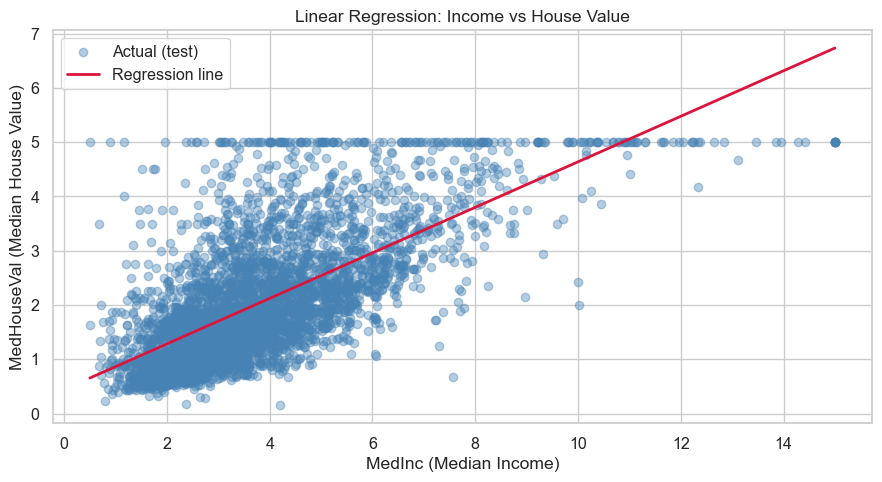

In [9]:
# Visualization 1: Scatter plot with regression line
plt.figure(figsize=(9, 5))
plt.scatter(X_test_r, y_test_r, alpha=0.4, label='Actual (test)', color='steelblue')
x_line = np.linspace(X_train_r.min(), X_train_r.max(), 100).reshape(-1, 1)
plt.plot(x_line, reg_model.predict(x_line), color='crimson', linewidth=2, label='Regression line')
plt.xlabel('MedInc (Median Income)')
plt.ylabel('MedHouseVal (Median House Value)')
plt.title('Linear Regression: Income vs House Value')
plt.legend()
plt.tight_layout()
plt.show()


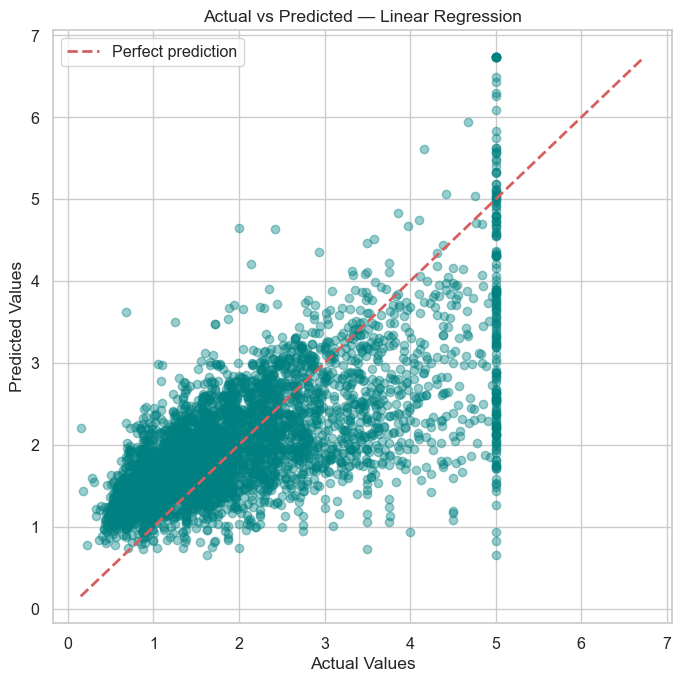

In [10]:
# Visualization 2: Actual vs Predicted (points near diagonal = good predictions)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='teal')
min_val, max_val = min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()


---

# Part 2: Classification

## Simple Definition
**Classification** predicts a **category or class label** — spam/not spam, disease yes/no, flower species.

## Real-Life Example
Email filter labeling messages as **Spam** or **Not Spam**.

## When to Use It
When the output is discrete labels, not continuous numbers.

## Binary vs Multiclass
- **Binary:** 2 classes (Pass/Fail, Yes/No).
- **Multiclass:** 3+ classes (Iris species: setosa, versicolor, virginica).

## Key Theory — Logistic Regression (for classification)
Despite the name, logistic regression predicts **class probabilities** using the sigmoid function:

$$P(y=1|x) = \frac{1}{1 + e^{-(wx + b)}}$$

We use it here as a simple, fast baseline classifier.

## Evaluation Metrics

### Confusion Matrix
|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
Fraction of all predictions that are correct.

### Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$
Of all predicted positives, how many were actually positive? *("When we say yes, how often are we right?")*

### Recall (Sensitivity)
$$\text{Recall} = \frac{TP}{TP + FN}$$
Of all actual positives, how many did we find? *("Of all sick patients, how many did we catch?")*

### F1-Score
$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
Harmonic mean of precision and recall — balances both.

## ROC Curve (Binary Classification)
Plots **True Positive Rate (Recall)** vs **False Positive Rate** at different thresholds.
- **AUC** (Area Under Curve) near 1 = excellent separation.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Clear business decisions from labels | Accuracy misleading on imbalanced data |
| Rich metrics for medical/fraud use cases | Needs careful threshold tuning for binary |

## Common Mistakes
- Using accuracy alone when one class is rare.
- Not checking confusion matrix per class in multiclass problems.


### Classification — Dataset & Model

We use **Breast Cancer Wisconsin** (binary: malignant vs benign) for metrics and ROC,
and **Iris** (3 classes) for multiclass confusion matrix.


In [11]:
# Binary classification dataset
cancer = datasets.load_breast_cancer()
X_c, y_c = cancer.data, cancer.target  # 0=malignant, 1=benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

# Scale features — important for logistic regression
scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

clf_log = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_log.fit(X_train_c_s, y_train_c)
y_pred_c = clf_log.predict(X_test_c_s)

print('Binary classification: Breast Cancer (0=malignant, 1=benign)')
print(f'Test accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}')


Binary classification: Breast Cancer (0=malignant, 1=benign)
Test accuracy: 0.9825


In [12]:
# Classification metrics explained
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print('=== Classification Metrics ===')
print(f'Accuracy:  {acc:.4f} — overall correct predictions')
print(f'Precision: {prec:.4f} — of predicted benign, how many truly benign')
print(f'Recall:    {rec:.4f} — of actual benign, how many we caught')
print(f'F1-score:  {f1:.4f} — balance of precision and recall')
print('\nDetailed report per class:')
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))


=== Classification Metrics ===
Accuracy:  0.9825 — overall correct predictions
Precision: 0.9861 — of predicted benign, how many truly benign
Recall:    0.9861 — of actual benign, how many we caught
F1-score:  0.9861 — balance of precision and recall

Detailed report per class:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [13]:
# Manual calculation of precision and recall from confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
TN, FP, FN, TP = cm.ravel()  # For binary 2x2 matrix
manual_prec = TP / (TP + FP)
manual_rec = TP / (TP + FN)
manual_f1 = 2 * manual_prec * manual_rec / (manual_prec + manual_rec)

print('Confusion Matrix:')
print(cm)
print(f'\nTP={TP}, FP={FP}, FN={FN}, TN={TN}')
print(f'Manual Precision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {manual_prec:.4f}')
print(f'Manual Recall    = TP/(TP+FN) = {TP}/({TP}+{FN}) = {manual_rec:.4f}')
print(f'Manual F1        = {manual_f1:.4f}')


Confusion Matrix:
[[41  1]
 [ 1 71]]

TP=71, FP=1, FN=1, TN=41
Manual Precision = TP/(TP+FP) = 71/(71+1) = 0.9861
Manual Recall    = TP/(TP+FN) = 71/(71+1) = 0.9861
Manual F1        = 0.9861


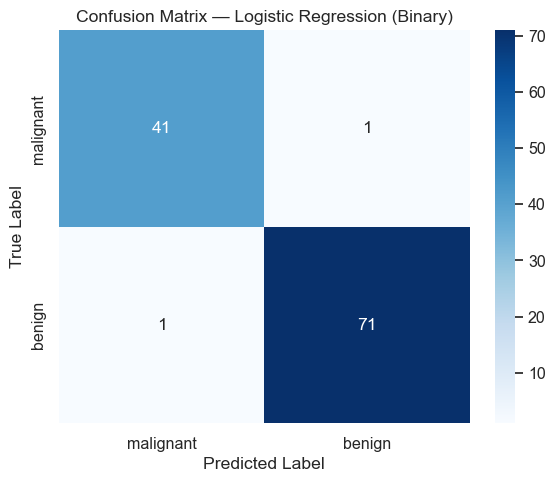

In [14]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Logistic Regression (Binary)')
plt.tight_layout()
plt.show()


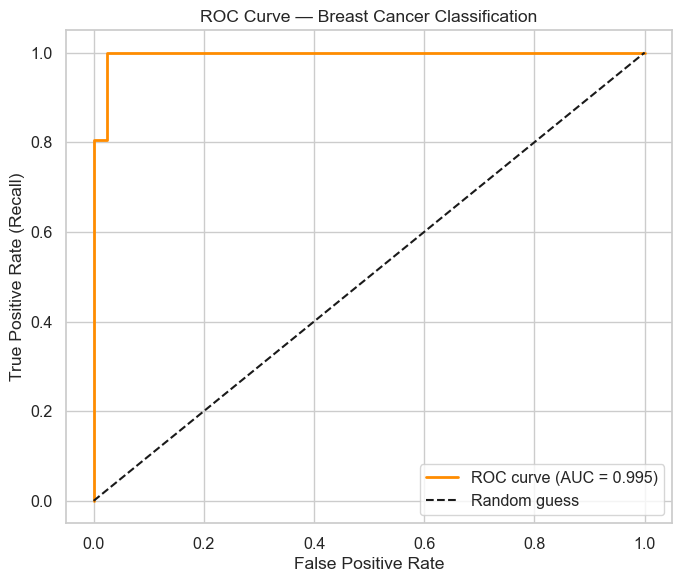

ROC explains: at each threshold, trade-off between catching positives (TPR) vs false alarms (FPR).


In [15]:
# ROC curve (binary classification only)
y_scores = clf_log.predict_proba(X_test_c_s)[:, 1]  # Probability of class 1 (benign)
fpr, tpr, thresholds = roc_curve(y_test_c, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Breast Cancer Classification')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
print('ROC explains: at each threshold, trade-off between catching positives (TPR) vs false alarms (FPR).')


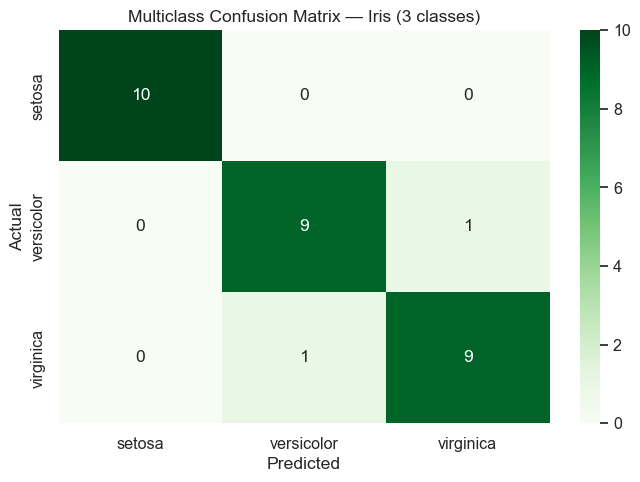

Multiclass accuracy: 0.9333


In [16]:
# Multiclass example with Iris (3 species)
X_ir, y_ir = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_ir, y_ir, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ir
)
scaler_i = StandardScaler()
X_tr_i_s = scaler_i.fit_transform(X_tr_i)
X_te_i_s = scaler_i.transform(X_te_i)

clf_multi = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_multi.fit(X_tr_i_s, y_tr_i)
y_pred_i = clf_multi.predict(X_te_i_s)

cm_multi = confusion_matrix(y_te_i, y_pred_i)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix — Iris (3 classes)')
plt.tight_layout()
plt.show()
print(f'Multiclass accuracy: {accuracy_score(y_te_i, y_pred_i):.4f}')


---

# Part 3: Decision Trees

## Simple Definition
A **decision tree** asks a series of yes/no questions about features until it reaches a **leaf** with a predicted class.

## Real-Life Example
A doctor's flowchart: "Fever?" → "Cough?" → "Diagnosis: Flu."

## When to Use It
- You need an **interpretable** model (easy to explain).
- Features are mixed numeric and categorical.
- Non-linear relationships without manual feature engineering.

## Key Theory

### Gini Impurity
Measures how mixed a node is (0 = pure, all one class):

$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$

| Term | Meaning |
|---|---|
| $K$ | Number of classes |
| $p_k$ | Proportion of class $k$ in the node |

### Entropy
$$\text{Entropy} = - \sum_{k=1}^{K} p_k \log_2(p_k)$$

Higher entropy = more disorder / mixed classes.

### Information Gain
$$\text{Information Gain} = \text{Entropy(parent)} - \text{Weighted Entropy(children)}$$

The tree picks the split that **maximizes information gain** (or minimizes Gini).

### Tree Depth & Leaf Nodes
- **Depth:** Longest path from root to leaf.
- **Leaf nodes:** Final prediction nodes (no further splits).

### Overfitting in Trees
Deep trees memorize training noise. Fix with `max_depth`, `min_samples_leaf`, or pruning.

## Step-by-Step (Training a Decision Tree)
1. Start with all data at the root.
2. Try every feature and split point.
3. Choose the split with best Gini/entropy reduction.
4. Repeat recursively until stopping rule (max depth, min samples).
5. Assign majority class at each leaf.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Very interpretable | Overfits easily if unconstrained |
| No scaling needed | Unstable — small data change can change tree |
| Handles non-linear patterns | Biased toward dominant classes |

## Common Mistakes
- Using default unlimited depth on noisy data.
- Expecting the same tree structure on slightly different training samples.


In [17]:
# Decision Tree on Iris (use 2 features for visualization)
X_dt = iris.data[:, [0, 1]]  # sepal length & width
y_dt = iris.target

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dt
)

# Limit max_depth to reduce overfitting (beginner-friendly setting)
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_clf.fit(X_train_dt, y_train_dt)
y_pred_dt = tree_clf.predict(X_test_dt)

print(f'Decision Tree test accuracy: {accuracy_score(y_test_dt, y_pred_dt):.4f}')
print(f'Tree depth (actual): {tree_clf.get_depth()}, Leaves: {tree_clf.get_n_leaves()}')


Decision Tree test accuracy: 0.6667
Tree depth (actual): 3, Leaves: 7


In [18]:
# Manual Gini impurity example: node with 3 classes [6, 2, 2] out of 10 samples
counts = np.array([6, 2, 2])
probs = counts / counts.sum()
gini_manual = 1 - np.sum(probs ** 2)
entropy_manual = -np.sum(probs * np.log2(probs + 1e-12))

print('Class counts:', counts, '→ proportions:', np.round(probs, 2))
print(f'Manual Gini:    {gini_manual:.4f}  (0=pure, higher=mixed)')
print(f'Manual Entropy: {entropy_manual:.4f}  (0=pure, higher=mixed)')


Class counts: [6 2 2] → proportions: [0.6 0.2 0.2]
Manual Gini:    0.5600  (0=pure, higher=mixed)
Manual Entropy: 1.3710  (0=pure, higher=mixed)


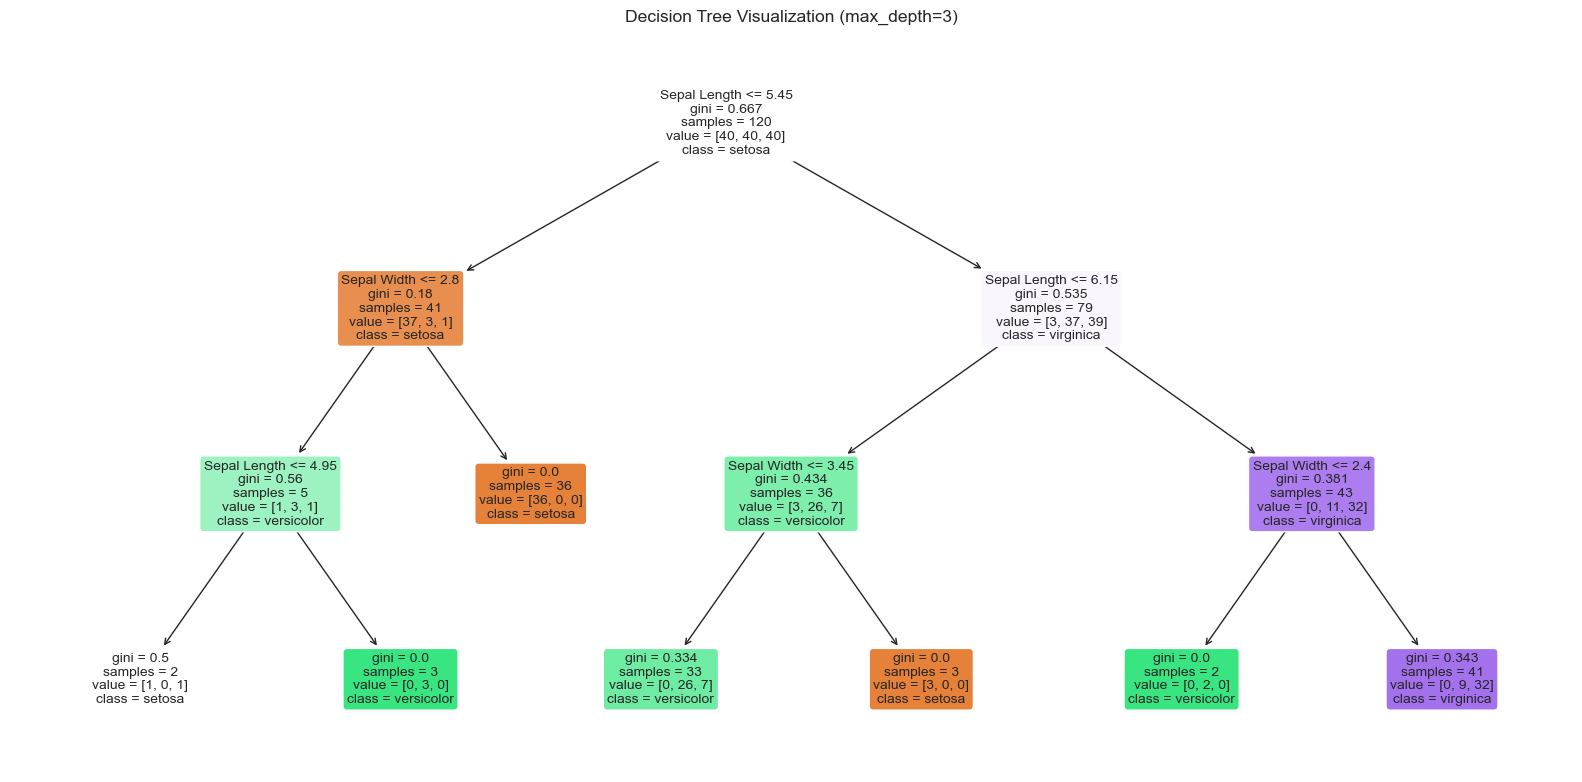

In [19]:
# Plot the decision tree structure
plt.figure(figsize=(16, 8))
plot_tree(tree_clf, feature_names=['Sepal Length', 'Sepal Width'],
          class_names=iris.target_names, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.tight_layout()
plt.show()


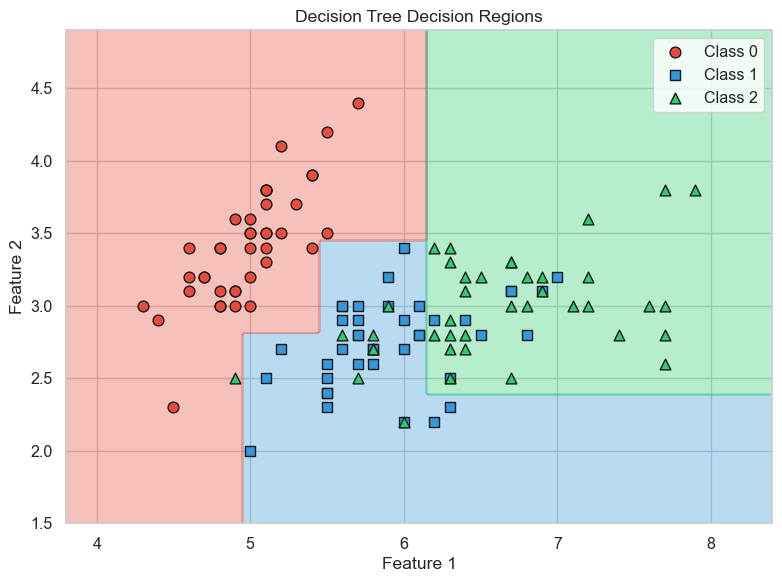

In [20]:
# Decision boundary plot
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train_dt, y_train_dt, tree_clf, title='Decision Tree Decision Regions')
plt.tight_layout()
plt.show()


---

# Part 4: Naive Bayes Algorithm

## Simple Definition
**Naive Bayes** classifies by combining **prior beliefs** about classes with **evidence** from features, assuming features are **independent** (the "naive" part).

## Real-Life Example
Spam filter: "If email contains 'free' and 'winner', what's the probability it's spam given past emails?"

## When to Use It
- Text classification (spam, sentiment).
- Fast baseline with small data.
- Many features (especially word counts).

## Bayes' Theorem

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

For classification with features $x$ and class $c$:

$$P(c|x) = \frac{P(x|c) \cdot P(c)}{P(x)}$$

| Term | Meaning |
|---|---|
| $P(c)$ | **Prior** — how common class $c$ is before seeing features |
| $P(x|c)$ | **Likelihood** — how likely features $x$ appear in class $c$ |
| $P(c|x)$ | **Posterior** — updated belief about class after seeing $x$ |
| $P(x)$ | Evidence (normalizing constant) |

## Naive Independence Assumption

$$P(x|c) = P(x_1|c) \cdot P(x_2|c) \cdots P(x_n|c)$$

Assumes features don't influence each other — rarely true, but often works well anyway.

## Gaussian Naive Bayes
For continuous features, each feature within a class is modeled as a **Gaussian (normal) distribution**.

## Step-by-Step
1. Estimate prior $P(c)$ from class frequencies in training data.
2. Estimate likelihood parameters (mean/variance per feature per class).
3. For a new sample, compute posterior for each class.
4. Predict the class with highest posterior.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Very fast training and prediction | Independence assumption often violated |
| Works well with high dimensions | Poor if features are strongly correlated |
| Good for text with Multinomial NB | Continuous data needs Gaussian NB assumptions |

## Common Mistakes
- Using Gaussian NB on count/text data without Multinomial/Bernoulli variants.
- Forgetting that probabilities can be miscalibrated even when classification is good.


In [21]:
# Gaussian Naive Bayes on Iris
X_nb = iris.data
y_nb = iris.target

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_nb
)

gnb = GaussianNB()
gnb.fit(X_train_nb, y_train_nb)
y_pred_nb = gnb.predict(X_test_nb)

print('Gaussian Naive Bayes — Iris classification')
print(f'Test accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}')
print('\nClass priors P(c) learned from training data:')
for name, p in zip(iris.target_names, gnb.class_prior_):
    print(f'  {name}: {p:.3f}')


Gaussian Naive Bayes — Iris classification
Test accuracy: 0.9667

Class priors P(c) learned from training data:
  setosa: 0.333
  versicolor: 0.333
  virginica: 0.333


In [22]:
# Posterior probabilities for first 5 test samples
proba_nb = gnb.predict_proba(X_test_nb[:5])
proba_df = pd.DataFrame(proba_nb, columns=iris.target_names).round(3)
proba_df['Predicted'] = iris.target_names[y_pred_nb[:5]]
proba_df['Actual'] = iris.target_names[y_test_nb[:5]]
print('Posterior probabilities P(class|x) for 5 test flowers:')
print(proba_df.to_string(index=False))


Posterior probabilities P(class|x) for 5 test flowers:
 setosa  versicolor  virginica  Predicted     Actual
    1.0       0.000      0.000     setosa     setosa
    0.0       0.088      0.912  virginica  virginica
    0.0       1.000      0.000 versicolor versicolor
    0.0       1.000      0.000 versicolor versicolor
    1.0       0.000      0.000     setosa     setosa


In [23]:
# Manual Bayes-style intuition (simplified 1-feature toy example)
# Suppose: P(spam)=0.4, P(word|spam)=0.3, P(word|not spam)=0.05
P_spam = 0.4
P_not = 0.6
P_word_given_spam = 0.3
P_word_given_not = 0.05
P_word = P_word_given_spam * P_spam + P_word_given_not * P_not
P_spam_given_word = (P_word_given_spam * P_spam) / P_word

print('Toy spam example with Bayes theorem:')
print(f'Prior P(spam) = {P_spam}')
print(f'Likelihood P(word|spam) = {P_word_given_spam}')
print(f'Evidence P(word) = {P_word:.4f}')
print(f'Posterior P(spam|word) = {P_spam_given_word:.4f}  → classify as spam if > 0.5')


Toy spam example with Bayes theorem:
Prior P(spam) = 0.4
Likelihood P(word|spam) = 0.3
Evidence P(word) = 0.1500
Posterior P(spam|word) = 0.8000  → classify as spam if > 0.5


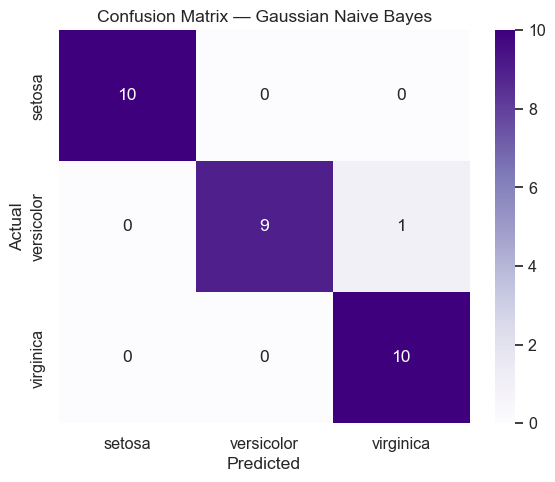

In [24]:
# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Gaussian Naive Bayes')
plt.tight_layout()
plt.show()


---

# Part 5: Support Vector Machines (SVM)

## Simple Definition
**SVM** finds the **best boundary** (hyperplane) that separates classes with the **maximum margin** — the widest gap between classes.

## Real-Life Example
Drawing the thickest possible line between red and blue dots on paper — that line is the decision boundary.

## When to Use It
- Clear margin of separation in feature space.
- Medium-sized datasets with effective scaling.
- Text and image classification (with kernels).

## Key Theory

### Hyperplane
Decision boundary: $w \cdot x + b = 0$

### Margin
Distance between the hyperplane and the nearest points from each class.

### Support Vectors
Training points closest to the boundary — they "support" the hyperplane. Removing other points often doesn't change the model.

### Kernel Trick
Maps data to higher dimensions so non-linear patterns become linearly separable.

- **Linear kernel:** Straight boundary — fast, works when data is linearly separable.
- **RBF kernel:** Flexible curved boundaries — good default for non-linear data.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Effective in high dimensions | Slow on very large datasets |
| Memory efficient (uses support vectors) | Needs feature scaling |
| Versatile with kernels | Hard to interpret vs trees |

## Common Mistakes
- Forgetting to scale features.
- Using RBF without tuning `C` and `gamma` on imbalanced or noisy data.


In [25]:
# SVM on 2-D Iris subset for decision boundary visualization
X_svm = iris.data[:, [0, 1]]
y_svm = iris.target

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=RANDOM_STATE, stratify=y_svm
)

scaler_svm = StandardScaler()
X_train_svm_s = scaler_svm.fit_transform(X_train_svm)
X_test_svm_s = scaler_svm.transform(X_test_svm)

# Linear SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
svm_linear.fit(X_train_svm_s, y_train_svm)
y_pred_svm_lin = svm_linear.predict(X_test_svm_s)

# RBF (non-linear) SVM
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_rbf.fit(X_train_svm_s, y_train_svm)
y_pred_svm_rbf = svm_rbf.predict(X_test_svm_s)

print(f'Linear SVM accuracy: {accuracy_score(y_test_svm, y_pred_svm_lin):.4f}')
print(f'RBF SVM accuracy:    {accuracy_score(y_test_svm, y_pred_svm_rbf):.4f}')
print(f'Number of support vectors (linear): {len(svm_linear.support_vectors_)}')


Linear SVM accuracy: 0.7333
RBF SVM accuracy:    0.7333
Number of support vectors (linear): 59


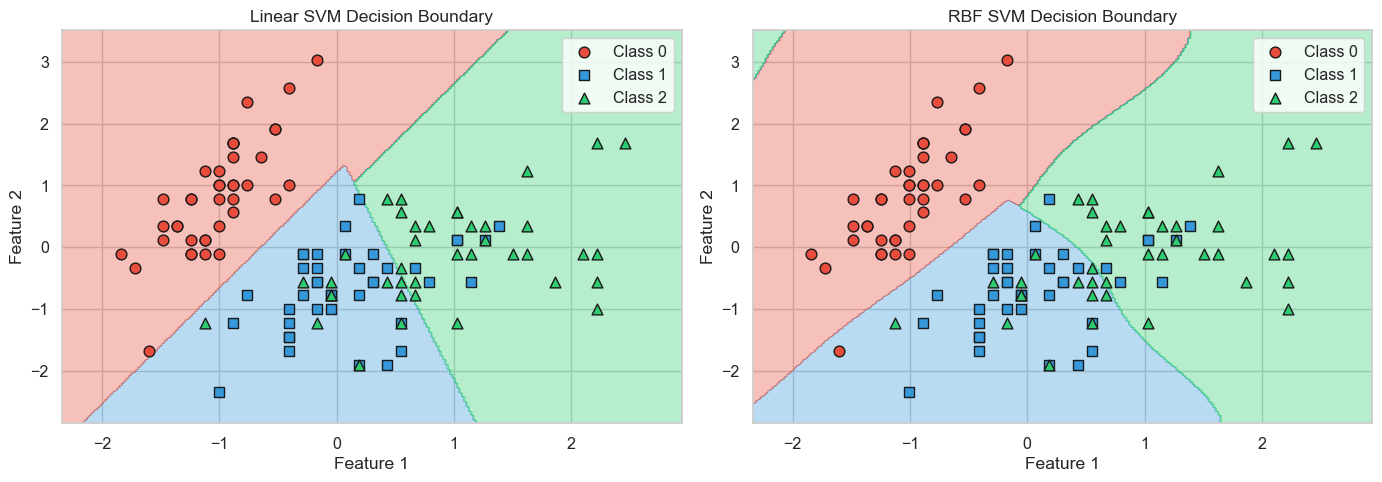

In [26]:
# Compare linear vs RBF decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [svm_linear, svm_rbf],
    ['Linear SVM Decision Boundary', 'RBF SVM Decision Boundary']
):
    plt.sca(ax)
    plot_decision_regions(X_train_svm_s, y_train_svm, model, title=title)

plt.tight_layout()
plt.show()


---

# Part 6: Ensemble Learning

## Simple Definition
**Ensemble learning** combines multiple models so their **collective prediction** is better than any single model alone.

## Real-Life Example
Asking five doctors for a diagnosis and taking a majority vote — usually more reliable than one opinion.

## When to Use It
- Single models plateau in performance.
- You can afford extra training time.
- Competitions and production systems needing strong accuracy.

## Key Concepts

### Bagging (Bootstrap Aggregating)
Train many models on **random subsets** of data (with replacement), then **average/vote**.
- **Random Forest:** Bagging + decision trees with random feature subsets.

### Boosting
Train models **sequentially**; each new model focuses on mistakes of previous ones.
- **Gradient Boosting:** Builds trees to correct residual errors.

### Voting Classifier
Combines different algorithm types (e.g., KNN + SVM + Decision Tree) by majority vote.

## Why Ensembles Improve Performance
- **Reduce variance** (bagging): averaging unstable models stabilizes predictions.
- **Reduce bias** (boosting): successive models fix systematic errors.
- **Diversity:** Different models make different mistakes; combining cancels some errors.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Often best accuracy | Slower training and prediction |
| Robust to overfitting (bagging/RF) | Less interpretable |
| Flexible combinations | Boosting can overfit if not tuned |

## Common Mistakes
- Stacking many identical models (no diversity).
- Using boosting without validation on noisy labels.


In [27]:
# Ensemble comparison on Breast Cancer (scaled features)
X_e, y_e = cancer.data, cancer.target
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e, y_e, test_size=0.2, random_state=RANDOM_STATE, stratify=y_e
)
scaler_e = StandardScaler()
X_train_e_s = scaler_e.fit_transform(X_train_e)
X_test_e_s = scaler_e.transform(X_test_e)

# Individual and ensemble models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Bagging (DT)': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        n_estimators=50, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Voting Classifier': VotingClassifier(estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ], voting='soft')
}

results = []
for name, model in models.items():
    model.fit(X_train_e_s, y_train_e)
    y_pred_e = model.predict(X_test_e_s)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_e, y_pred_e),
        'Precision': precision_score(y_test_e, y_pred_e),
        'Recall': recall_score(y_test_e, y_pred_e),
        'F1': f1_score(y_test_e, y_pred_e),
    })

ensemble_df = pd.DataFrame(results).round(4)
print('=== Ensemble Model Comparison ===')
print(ensemble_df.to_string(index=False))


=== Ensemble Model Comparison ===
            Model  Accuracy  Precision  Recall     F1
    Decision Tree    0.9211     0.9565  0.9167 0.9362
     Bagging (DT)    0.9386     0.9452  0.9583 0.9517
    Random Forest    0.9561     0.9589  0.9722 0.9655
Gradient Boosting    0.9561     0.9467  0.9861 0.9660
Voting Classifier    0.9649     0.9595  0.9861 0.9726


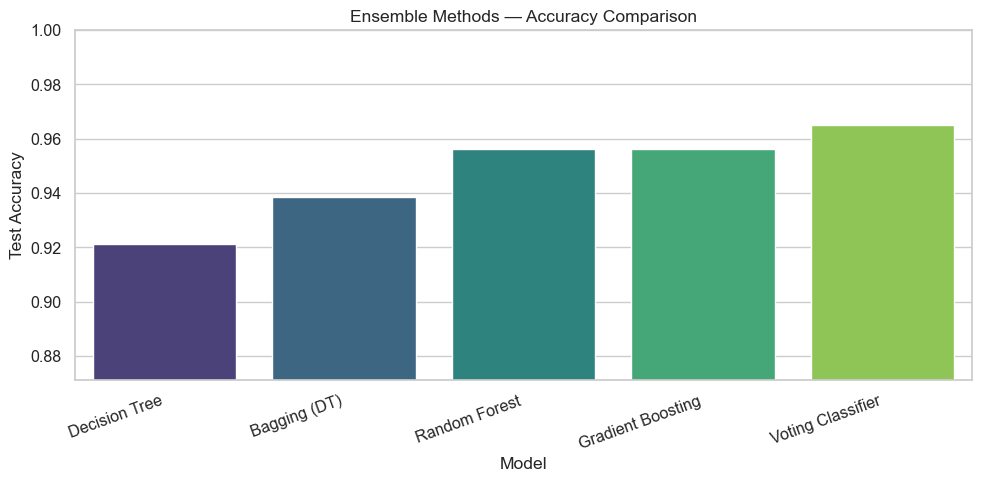

Notice: ensembles often outperform a single shallow decision tree.


In [28]:
# Bar chart comparing ensemble models
plt.figure(figsize=(10, 5))
sns.barplot(data=ensemble_df, x='Model', y='Accuracy', palette='viridis')
plt.xticks(rotation=20, ha='right')
plt.ylim(ensemble_df['Accuracy'].min() - 0.05, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Ensemble Methods — Accuracy Comparison')
plt.tight_layout()
plt.show()
print('Notice: ensembles often outperform a single shallow decision tree.')


---

# Part 7: K-Nearest Neighbors (KNN)

## Simple Definition
**KNN** classifies a new point by looking at the **K closest training examples** and taking a **majority vote** (classification) or average (regression).

## Real-Life Example
Choosing a restaurant by finding the 5 most similar neighborhoods to yours and seeing which cuisine they prefer.

## When to Use It
- Simple baseline for small/medium datasets.
- Decision boundary is irregular.
- Lazy learning — no explicit training phase.

## Euclidean Distance

$$d(x, x') = \sqrt{\sum_{j=1}^{n} (x_j - x'_j)^2}$$

| Term | Meaning |
|---|---|
| $x, x'$ | Two data points |
| $x_j$ | Value of feature $j$ |
| $n$ | Number of features |

## Choosing K
- **Small K** (e.g., 1): flexible boundary, risk of overfitting.
- **Large K** (e.g., 50): smoother boundary, risk of underfitting.
- Use cross-validation to pick K.

## Effect of Scaling
KNN is **distance-based** — features with larger numeric ranges dominate distance. **Always scale** for KNN.

## Step-by-Step
1. Store all training data.
2. For a new point, compute distance to every training point.
3. Select K nearest neighbors.
4. Majority vote → predicted class.

## Advantages & Disadvantages
| Advantages | Disadvantages |
|---|---|
| Simple to understand | Slow prediction on large data |
| No training phase | Sensitive to irrelevant features |
| Non-linear boundaries | Requires scaling |

## Common Mistakes
- Using KNN without scaling.
- Using even K in binary classification (ties possible — use odd K).
- Ignoring curse of dimensionality in very high dimensions.


In [29]:
# KNN on 2-D Iris for visualization
X_knn = iris.data[:, [0, 1]]
y_knn = iris.target

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_knn
)

scaler_knn = StandardScaler()
X_train_knn_s = scaler_knn.fit_transform(X_train_knn)
X_test_knn_s = scaler_knn.transform(X_test_knn)

# Compare different K values
k_values = [1, 3, 5, 15, 30]
knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn_s, y_train_knn)
    acc = accuracy_score(y_test_knn, knn.predict(X_test_knn_s))
    knn_results.append({'K': k, 'Accuracy': acc})

knn_df = pd.DataFrame(knn_results)
print('Accuracy for different K values:')
print(knn_df.to_string(index=False))


Accuracy for different K values:
 K  Accuracy
 1  0.700000
 3  0.666667
 5  0.633333
15  0.700000
30  0.700000


In [30]:
# Manual Euclidean distance between two points
point_a = np.array([5.1, 3.5])
point_b = np.array([4.9, 3.0])
manual_dist = np.sqrt(np.sum((point_a - point_b) ** 2))
print(f'Point A: {point_a}, Point B: {point_b}')
print(f'Manual Euclidean distance: {manual_dist:.4f}')
print('KNN finds K training points with smallest distances like this one.')


Point A: [5.1 3.5], Point B: [4.9 3. ]
Manual Euclidean distance: 0.5385
KNN finds K training points with smallest distances like this one.


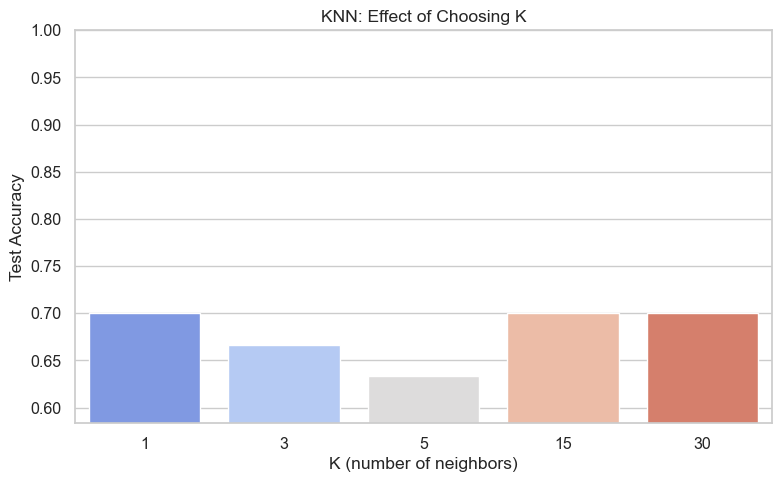

In [31]:
# Bar chart: accuracy vs K
plt.figure(figsize=(8, 5))
sns.barplot(data=knn_df, x='K', y='Accuracy', palette='coolwarm')
plt.ylim(knn_df['Accuracy'].min() - 0.05, 1.0)
plt.xlabel('K (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN: Effect of Choosing K')
plt.tight_layout()
plt.show()


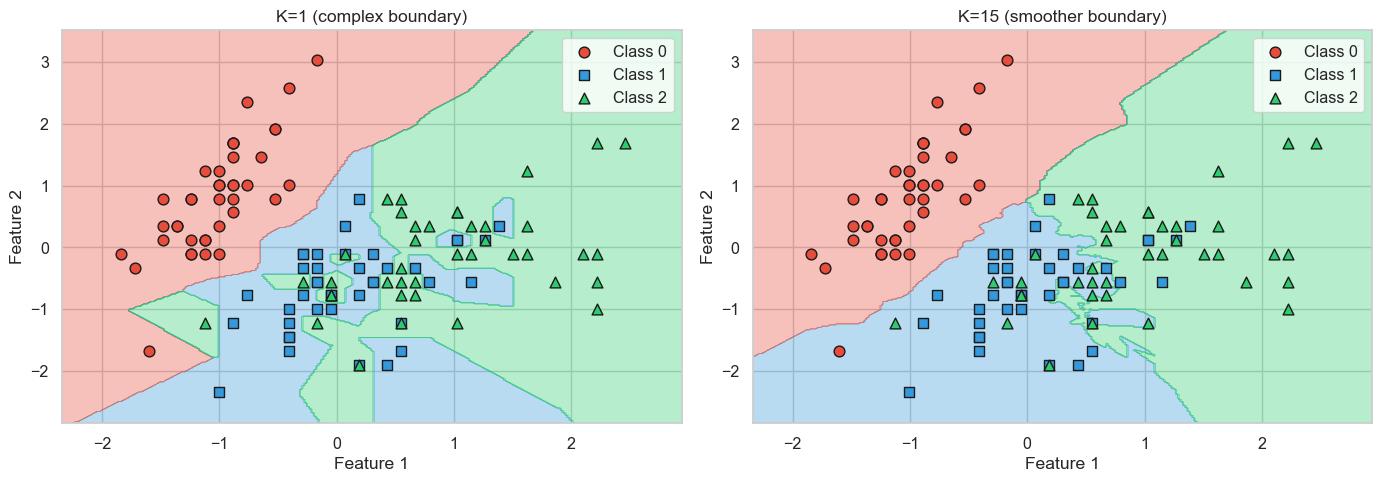

In [32]:
# Decision boundary for K=1 vs K=15 (overfitting vs smoother boundary)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, k, subtitle in zip(axes, [1, 15], ['K=1 (complex boundary)', 'K=15 (smoother boundary)']):
    knn_plot = KNeighborsClassifier(n_neighbors=k)
    knn_plot.fit(X_train_knn_s, y_train_knn)
    plt.sca(ax)
    plot_decision_regions(X_train_knn_s, y_train_knn, knn_plot, title=subtitle)
plt.tight_layout()
plt.show()


In [33]:
# Effect of scaling demo: same KNN with and without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train_knn, y_train_knn)
acc_unscaled = accuracy_score(y_test_knn, knn_unscaled.predict(X_test_knn))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_knn_s, y_train_knn)
acc_scaled = accuracy_score(y_test_knn, knn_scaled.predict(X_test_knn_s))

print(f'KNN (K=5) WITHOUT scaling — accuracy: {acc_unscaled:.4f}')
print(f'KNN (K=5) WITH scaling    — accuracy: {acc_scaled:.4f}')
print('Scaling often improves KNN because all features contribute fairly to distance.')


KNN (K=5) WITHOUT scaling — accuracy: 0.7667
KNN (K=5) WITH scaling    — accuracy: 0.6333
Scaling often improves KNN because all features contribute fairly to distance.


---

# Final Summary

## Algorithm Comparison Table

Below we train all major classifiers on the same binary task and compare metrics fairly.


In [34]:
# Final comparison on Breast Cancer dataset (same split for all models)
X_f, y_f = cancer.data, cancer.target
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=RANDOM_STATE, stratify=y_f
)
scaler_f = StandardScaler()
X_tr_f_s = scaler_f.fit_transform(X_tr_f)
X_te_f_s = scaler_f.transform(X_te_f)

final_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Gaussian Naive Bayes': GaussianNB(),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

final_results = []
for name, model in final_models.items():
    model.fit(X_tr_f_s, y_tr_f)
    pred = model.predict(X_te_f_s)
    final_results.append({
        'Algorithm': name,
        'Accuracy': accuracy_score(y_te_f, pred),
        'Precision': precision_score(y_te_f, pred),
        'Recall': recall_score(y_te_f, pred),
        'F1-Score': f1_score(y_te_f, pred),
    })

final_df = pd.DataFrame(final_results).round(4).sort_values('F1-Score', ascending=False)
print('=== Final Algorithm Comparison (Breast Cancer) ===')
print(final_df.to_string(index=False))


=== Final Algorithm Comparison (Breast Cancer) ===
           Algorithm  Accuracy  Precision  Recall  F1-Score
 Logistic Regression    0.9825     0.9861  0.9861    0.9861
           SVM (RBF)    0.9825     0.9861  0.9861    0.9861
   Gradient Boosting    0.9561     0.9467  0.9861    0.9660
           KNN (K=5)    0.9561     0.9589  0.9722    0.9655
       Random Forest    0.9561     0.9589  0.9722    0.9655
Gaussian Naive Bayes    0.9298     0.9444  0.9444    0.9444
       Decision Tree    0.9211     0.9565  0.9167    0.9362


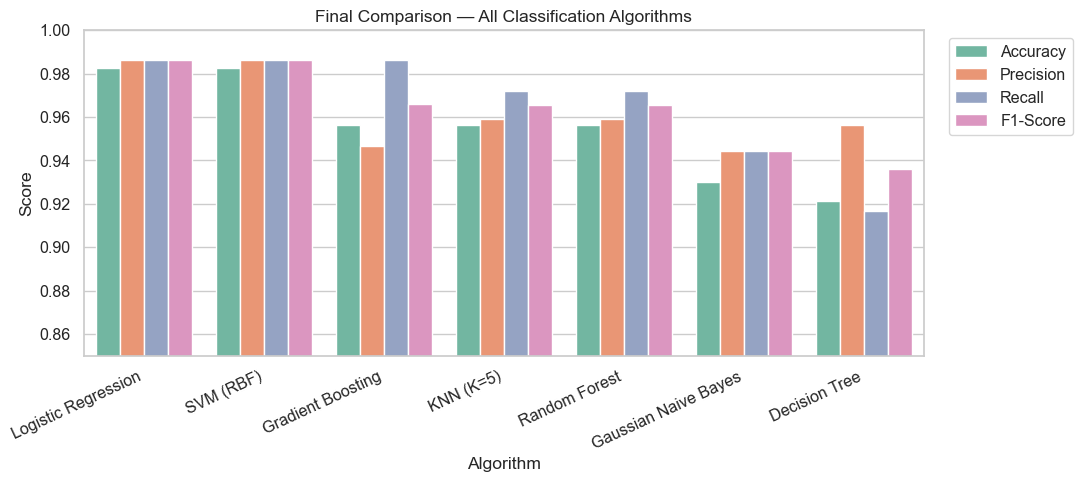

In [35]:
plt.figure(figsize=(11, 5))
plot_df = final_df.melt(id_vars='Algorithm', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                        var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Algorithm', y='Score', hue='Metric', palette='Set2')
plt.xticks(rotation=25, ha='right')
plt.ylim(0.85, 1.0)
plt.title('Final Comparison — All Classification Algorithms')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Which Algorithm to Choose and When?

| Goal | Recommended Starting Point | Why |
|---|---|---|
| Predict a **number** | Linear Regression | Simple, fast, interpretable baseline |
| **Binary** classification, need probabilities | Logistic Regression | Probabilities + interpretable coefficients |
| Need **explainable** rules | Decision Tree (shallow) | Easy to visualize and explain |
| **Text / spam** classification | Naive Bayes | Fast, works well with word features |
| **High-dimensional** data, clear margin | SVM with RBF kernel | Strong boundaries with scaling |
| **Best accuracy**, have compute time | Random Forest / Gradient Boosting | Ensembles reduce error |
| **Simple baseline**, small data | KNN | No training; good teaching tool |
| **Imbalanced** classes | Focus on Precision/Recall/F1, not accuracy alone | Accuracy hides failure on minority class |

**Practical workflow for beginners:**
1. Split data (train/test) and avoid data leakage.
2. Scale if using KNN, SVM, or logistic regression.
3. Train a **simple baseline** (linear/logistic or KNN).
4. Try **tree-based ensembles** if you need better performance.
5. Compare metrics on **test data** once — not repeatedly tuning on test.


## Practice Questions

1. What is the difference between **regression** and **classification**? Give one example of each.
2. Why should we **never** evaluate a model only on training data?
3. Explain **overfitting** in your own words. How can `max_depth` in a decision tree help?
4. Write the formula for **F1-score** and explain when precision matters more than recall.
5. What is the **naive assumption** in Naive Bayes? Why does it still work in practice?
6. Why must we **scale features** before KNN but not necessarily before Random Forest?
7. What is the difference between **bagging** and **boosting**?
8. In SVM, what are **support vectors**?
9. Calculate **MAE** by hand for actual values `[3, 5, 2]` and predictions `[2, 6, 2]`.
10. What is **data leakage**? Give one example.


## Mini Project Ideas

1. **House Price Predictor:** Download a housing CSV, predict price from 3+ features, report RMSE and R².
2. **Iris Species Classifier:** Build a notebook section comparing KNN, SVM, and Random Forest on Iris; include confusion matrices.
3. **Student Pass/Fail:** Create synthetic student data (study hours, attendance), train logistic regression, plot ROC curve.
4. **Spam SMS Classifier:** Use a public SMS spam dataset with Multinomial Naive Bayes (text counts).
5. **Customer Churn:** Binary classification with imbalanced classes — compare accuracy vs F1 and try Random Forest.
6. **K Tuning Report:** On any dataset, plot accuracy vs K for KNN from 1 to 30 using cross-validation.

---

## Congratulations!

You have worked through the core supervised learning algorithms taught in introductory ML courses.
Re-run this notebook, change `random_state`, adjust hyperparameters, and experiment — that is how intuition grows.

**Next steps:** Chapter 4 in this course covers model tuning, cross-validation in depth, and advanced ensembles (XGBoost, stacking).
